# Prediction using Decision Tree Algorithm
**Author: Ishani Kathuria**

Given a dataset with Sepal and Petal lengths and width of flowers, I trained a Decision Tree Algorithm that would then be able to classify the data into the different target species.

In [1]:
# importing the necessary packages
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
pd.set_option('display.max_rows', None)

In [2]:
# importing the dataset as a pandas dataframe
import kagglehub

path = kagglehub.dataset_download("uciml/iris")  # downloads once, then cached
complete_data = pd.read_csv(f"{path}/Iris.csv").drop(columns='Id')
complete_data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
species_dict = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
target_names = [i for i in species_dict.keys()]
y = np.array([species_dict[i] for i in complete_data.iloc[:,4].values])

complete_data['SpeciesTrue'] = pd.Series(y)
y = complete_data['SpeciesTrue']

complete_data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,SpeciesTrue
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [4]:
x = complete_data.iloc[:,:4]
feature_names = [i for i in x.columns]
x.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
target_names, feature_names

(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
 ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])

## Train Test Split

**x** contains all the feature values and **y** contains the target values. These were separated into training and testing datasets using `train_test_split`

In [6]:
x.shape, y.shape

((150, 4), (150,))

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [9]:
print('Shape of training features', x_train.shape)
print('Shape of testing features', x_test.shape)
print('Shape of training targets', y_train.shape)
print('Shape of testing targets', y_test.shape)

Shape of training features (120, 4)
Shape of testing features (30, 4)
Shape of training targets (120,)
Shape of testing targets (30,)


## Decision Tree Model

A decision tree is a graphical tree like model of decisions which divides the data into different categories based on the different features and outcomes.

<img src="https://d2h0cx97tjks2p.cloudfront.net/blogs/wp-content/uploads/sites/2/2017/07/Decision-Trees-Example.png" >

### Train and Visualize the model

I trained the model uing the `DecisionTreeClassifier` from sklearn and visualized the graph in a test format, a sklearn plot and a dtreeviz plot.

In [10]:
from sklearn import tree

In [11]:
dtree = tree.DecisionTreeClassifier()
dtree.fit(x_train, y_train)

DecisionTreeClassifier()

In [12]:
text_representation = tree.export_text(dtree, feature_names=feature_names)
print(text_representation)

|--- PetalWidthCm <= 0.80
|   |--- class: 0
|--- PetalWidthCm >  0.80
|   |--- PetalWidthCm <= 1.75
|   |   |--- PetalLengthCm <= 4.95
|   |   |   |--- PetalWidthCm <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- PetalWidthCm >  1.65
|   |   |   |   |--- class: 2
|   |   |--- PetalLengthCm >  4.95
|   |   |   |--- PetalWidthCm <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- PetalWidthCm >  1.55
|   |   |   |   |--- PetalLengthCm <= 5.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- PetalLengthCm >  5.45
|   |   |   |   |   |--- class: 2
|   |--- PetalWidthCm >  1.75
|   |   |--- PetalLengthCm <= 4.85
|   |   |   |--- SepalLengthCm <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- SepalLengthCm >  5.95
|   |   |   |   |--- class: 2
|   |   |--- PetalLengthCm >  4.85
|   |   |   |--- class: 2



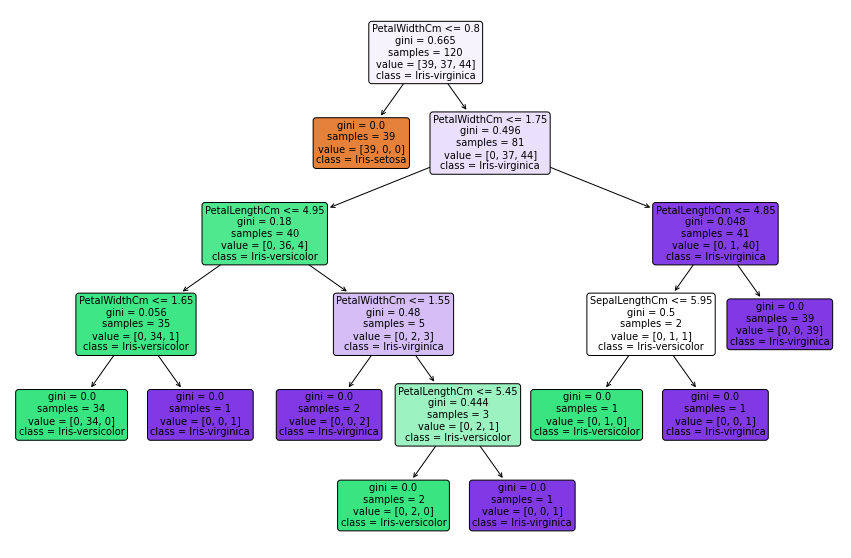

In [13]:
fig = plt.figure(figsize=(15,10))
_ = tree.plot_tree(dtree, feature_names=feature_names,
                   class_names=target_names,
                   filled=True, rounded=True)

In [14]:
from dtreeviz.trees import dtreeviz

findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


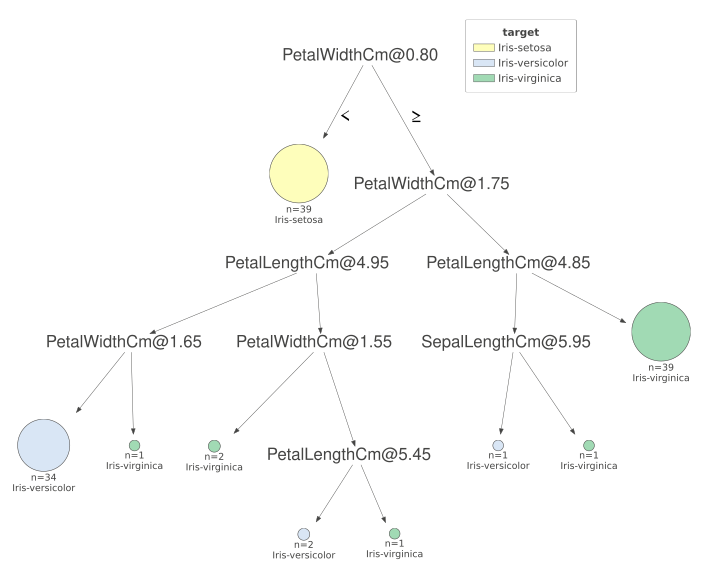

In [15]:
viz = dtreeviz(dtree, x_train, y_train,
               target_name="target",
               feature_names=feature_names,
               class_names=target_names,
               fancy=False,
               scale=1.4)
viz

### Test the model

In [16]:
y_pred = dtree.predict(x_test)

In [17]:
print('The True vs Predicted values')
pd.DataFrame(y_pred, y_test)

The True vs Predicted values


,0
SpeciesTrue,
2,2
1,1
0,0
2,2
0,0
2,2
0,0
1,1
1,1


### Evaluate the model

I evaluated the model using a `confusion_matrix` and checked the precision of the model using `classification_report`

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

In [19]:
report = classification_report(y_test, y_pred)
print('Classification report : \n', report)

conf_mat = confusion_matrix(y_test, y_pred)
fig = px.imshow(conf_mat, labels=dict(x='Predicted Values', y='True Values'),
                 title='Confusion Matrix',
                 x=target_names,
                 y=target_names,
                 color_continuous_scale='Magma')
fig.update_xaxes(side="top")
fig.show()

Classification report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Conclusion

The decision tree model performed better than the KMeans Clustering algorithm for the same dataset. The values were predicted with a precision of 1.0 for all 3 target species, which is the highest score possible.